## Run a pipeline

### Minimal Pipeline Execution: Runs in just **3 lines of code**

```python
from paidiverpy.pipeline import Pipeline
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()
```

### This is the configuration file:


```yaml
general:
  sample_data: "benthic_ifdo"
  output_path: "./output"
  n_jobs: 8
  sampling:
    - mode: "fixed"
      params:
        value: 5
  convert:
    - mode: "bits"
      params:
        output_bits: 8
steps:
  - colour:
      name: "colour_correction"
      mode: "grayscale"

  - sampling:
      name: "datetime"
      mode: "datetime"
      params:
        min: "2016-05-11 04:14:00"
        max: "2016-05-11 09:27:00"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "sharpen"
      mode: "sharpen"
      params:
        alpha: 1.5
        beta: -0.5

  - colour:
      name: "contrast"
      mode: "contrast"
```

### Sample data

This configuration file uses a part of our example data:

```yaml
general:
  sample_data: "benthic_ifdo"
```

In this case, it will download the data automatically. But you can also do it manually:

In [1]:
from paidiverpy.utils.data import PaidiverpyData

data = PaidiverpyData()
data.load("benthic_ifdo")

{'input_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/images',
 'metadata_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/metadata/metadata_benthic_ifdo.json',
 'metadata_type': 'IFDO',
 'image_open_args': 'JPG'}

## Running the code

In [2]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

In [3]:
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")

In [74]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [72]:
# See the pipeline steps in json format
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "raw",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "is_remote": false,
        "output_is_remote": false,
        "output_path": "output",
        "n_jobs": 1,
        "track_changes": true,
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "mode": "fixed",
                "params": {
                    "value": 20,
                    "raise_error": false
                }
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "mode": "grayscale",
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            }
        },
        {
            "name": "datetime",
            "step_name": "sampling",
            "test": false,
            "mode": "datetime",
            "params": {
                "min": "2018-06-11 04:14:00",
                "max": "2018-06-11 04:20:00",
                "raise_error": false
            }
        },
        {
            "name": "overlapping",
            "step_name": "sampling",
            "test": false,
            "mode": "overlapping",
            "params": {
                "omega": 57,
                "theta": 40,
                "threshold": 0.5,
                "camera_distance": 1.12,
                "raise_error": false
            }
        },
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "mode": "gaussian_blur",
            "params": {
                "sigma": 1.0,
                "raise_error": false
            }
        },
        {
            "name": "sharpen",
            "step_name": "colour",
            "test": false,
            "mode": "sharpen",
            "params": {
                "alpha": 1.5,
                "beta": -0.5,
                "raise_error": false
            }
        },
        {
            "name": "contrast",
            "step_name": "colour",
            "test": false,
            "mode": "contrast",
            "params": {
                "method": "clahe",
                "clip_limit": 0.01,
                "gamma_value": 0.5,
                "raise_error": false
            }
        },
        {
            "name": "corners",
            "step_name": "position",
            "test": false,
            "mode": "calculate_corners",
            "params": {
                "omega": 57,
                "theta": 40,
                "camera_distance": 1.12,
                "raise_error": false
            }
        }
    ]
}

In [48]:
pipeline.metadata

,image-filename,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,TRcornerlong,TRcornerlat,TLcornerlong,TLcornerlat,BLcornerlong,BLcornerlat,BRcornerlong,BRcornerlat,overlap,polygon_m
0,20180611041431.png,431.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:31,2.828427,FLASH,...,-153.605305,11.251705,-153.605305,11.251731,-153.605322,11.251731,-153.605322,11.251705,0,POLYGON ((-153.60532242262374 11.2517054397381...
1,20180611041451.png,433.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:51,2.828427,FLASH,...,-153.605305,11.251695,-153.605304,11.251721,-153.605322,11.251721,-153.605322,11.251696,1,POLYGON ((-153.60530450358652 11.2516954398786...
2,20180611041521.png,436.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:21,2.828427,FLASH,...,-153.605309,11.251678,-153.605308,11.251705,-153.605327,11.251705,-153.605327,11.251678,0,POLYGON ((-153.60530868210603 11.2516778018813...
3,20180611041531.png,437.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:31,2.828427,FLASH,...,-153.605312,11.251671,-153.605312,11.251696,-153.605329,11.251696,-153.605329,11.251671,1,POLYGON ((-153.60532918833948 11.2516707067058...
4,20180611041551.png,439.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:51,2.828427,FLASH,...,-153.605313,11.251654,-153.605313,11.251680,-153.605330,11.251680,-153.605330,11.251655,0,POLYGON ((-153.60531287424553 11.2516544199985...
5,20180611041621.png,442.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:21,2.828427,FLASH,...,-153.605313,11.251636,-153.605312,11.251662,-153.605330,11.251663,-153.605331,11.251636,0,POLYGON ((-153.60531250603074 11.2516357117654...
6,20180611041641.png,444.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:41,2.828427,FLASH,...,-153.605312,11.251629,-153.605311,11.251655,-153.605329,11.251655,-153.605329,11.251629,1,POLYGON ((-153.60531157256716 11.2516293035685...
7,20180611041701.png,446.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:01,2.828427,FLASH,...,-153.605311,11.251621,-153.605311,11.251647,-153.605329,11.251647,-153.605329,11.251622,0,POLYGON ((-153.60531148160254 11.2516213159115...
8,20180611041721.png,448.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:21,2.828427,FLASH,...,-153.605312,11.251617,-153.605311,11.251643,-153.605329,11.251643,-153.605329,11.251617,1,POLYGON ((-153.6053115481469 11.25161685953249...
9,20180611041731.png,449.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:31,2.828427,FLASH,...,-153.605309,11.251616,-153.605309,11.251642,-153.605327,11.251643,-153.605328,11.251616,1,POLYGON ((-153.60530948504496 11.2516156522718...


In [44]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:35 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:35 | Running step 0: raw - OpenLayer
☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:35 | Number of images to be removed: 29. Total number of images: 49


Open Images: 100%|█████████████████████████████████| 20/20 [00:00<00:00, 374.47it/s]


☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:35 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:35 | Running step 1: colour_correction - ColourLayer


Processing images: 100%|██████████████████████████| 20/20 [00:00<00:00, 6649.71it/s]

☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:35 | Step 1 completed


...

☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:36 | Step 4 completed
☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:36 | Running step 5: sharpen - ColourLayer



Processing images: 100%|████████████████████████████| 9/9 [00:00<00:00, 1538.69it/s]

☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:37 | Step 5 completed
☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:37 | Running step 6: contrast - ColourLayer



Processing images: 100%|█████████████████████████████| 9/9 [00:00<00:00, 250.75it/s]


☁ paidiverpy ☁  |       INFO | 2025-05-20 18:47:37 | Step 6 completed


In [20]:
pipeline.get_metadata()

,image-filename,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,TRcornerlong,TRcornerlat,TLcornerlong,TLcornerlat,BLcornerlong,BLcornerlat,BRcornerlong,BRcornerlat,overlap,polygon_m
0,20180611041431.png,431.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:31,2.828427,FLASH,...,-153.605305,11.251705,-153.605305,11.251731,-153.605322,11.251731,-153.605322,11.251705,0,POLYGON ((-153.60532242262374 11.2517054397381...
2,20180611041541.png,438.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:41,2.828427,FLASH,...,-153.605313,11.251663,-153.605312,11.251688,-153.605330,11.251689,-153.605330,11.251663,0,POLYGON ((-153.60531264279453 11.2516626734196...
3,20180611041601.png,440.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:01,2.828427,FLASH,...,-153.605313,11.251646,-153.605313,11.251673,-153.605331,11.251673,-153.605331,11.251646,0,POLYGON ((-153.6053128455258 11.25164646451044...
4,20180611041631.png,443.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:31,2.828427,FLASH,...,-153.605312,11.251634,-153.605312,11.251659,-153.605329,11.251660,-153.605330,11.251634,0,POLYGON ((-153.60531203486076 11.2516336560737...
7,20180611041701.png,446.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:01,2.828427,FLASH,...,-153.605311,11.251621,-153.605311,11.251647,-153.605329,11.251647,-153.605329,11.251622,0,POLYGON ((-153.60531148160254 11.2516213159115...
11,20180611041751.png,451.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:17:51,2.828427,FLASH,...,-153.605302,11.251615,-153.605302,11.251642,-153.605320,11.251642,-153.605320,11.251615,0,POLYGON ((-153.6053015951501 11.25161483159092...
12,20180611041811.png,453.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:11,2.828427,FLASH,...,-153.605289,11.251617,-153.605289,11.251647,-153.605309,11.251647,-153.605309,11.251617,0,POLYGON ((-153.6053089846491 11.25161735210587...
13,20180611041841.png,456.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:41,2.828427,FLASH,...,-153.605268,11.251624,-153.605268,11.251651,-153.605286,11.251652,-153.605287,11.251624,0,POLYGON ((-153.60526798471008 11.2516238013981...
14,20180611041951.png,463.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:19:51,2.828427,FLASH,...,-153.605212,11.251612,-153.605212,11.251639,-153.605230,11.251639,-153.605230,11.251612,0,POLYGON ((-153.6052301033692 11.25161193698947...


Step: raw
Image: [[[167 180 160 255]
  [169 180 160 255]
  [169 180 162 255]
  ...
  [206 203 162 255]
  [207 205 163 255]
  [206 204 161 255]]

 [[170 181 164 255]
  [170 180 161 255]
  [169 180 162 255]
  ...
  [207 205 162 255]
  [207 204 161 255]
  [208 204 163 255]]

 [[168 180 162 255]
  [170 181 165 255]
  [172 181 164 255]
  ...
  [208 205 164 255]
  [207 204 163 255]
  [209 205 163 255]]

 ...

 [[191 192 170 255]
  [191 194 170 255]
  [194 194 170 255]
  ...
  [215 208 169 255]
  [213 210 171 255]
  [215 209 170 255]]

 [[193 193 172 255]
  [193 195 171 255]
  [193 193 170 255]
  ...
  [213 207 168 255]
  [213 209 169 255]
  [212 208 171 255]]

 [[193 195 174 255]
  [194 194 170 255]
  [193 193 170 255]
  ...
  [214 207 168 255]
  [214 207 169 255]
  [215 208 171 255]]]
Image: [[[196 203 175 255]
  [198 203 176 255]
  [199 203 176 255]
  ...
  [210 206 166 255]
  [211 208 165 255]
  [211 208 167 255]]

 [[200 203 179 255]
  [198 202 176 255]
  [199 202 178 255]
  ...
  [211 208 167 255]
  [211 207 167 255]
  [213 208 170 255]]

 [[200 205 179 255]
  [201 204 179 255]
  [199 202 176 255]
  ...
  [213 208 168 255]
  [210 207 169 255]
  [213 208 170 255]]

 ...

 [[198 198 171 255]
  [199 198 174 255]
  [202 200 173 255]
  ...
  [211 208 172 255]
  [214 210 174 255]
  [213 209 175 255]]

 [[197 197 174 255]
  [198 198 174 255]
  [199 196 171 255]
  ...
  [213 209 173 255]
  [214 209 174 255]
  [214 209 174 255]]

 [[196 197 173 255]
  [198 196 172 255]
  [199 197 171 255]
  ...
  [211 207 172 255]
  [214 210 173 255]
  [214 209 176 255]]]
Image: [[[195 203 179 255]
  [195 204 180 255]
  [195 204 179 255]
  ...
  [211 208 171 255]
  [209 209 170 255]
  [210 208 171 255]]

 [[197 204 182 255]
  [197 202 179 255]
  [195 202 180 255]
  ...
  [210 209 171 255]
  [210 208 171 255]
  [212 210 173 255]]

 [[196 204 181 255]
  [195 203 180 255]
  [198 203 181 255]
  ...
  [211 208 173 255]
  [211 208 171 255]
  [211 209 171 255]]

 ...

 [[192 195 172 255]
  [195 197 175 255]
  [198 198 173 255]
  ...
  [203 203 173 255]
  [203 202 171 255]
  [203 203 173 255]]

 [[193 195 173 255]
  [193 195 173 255]
  [197 196 174 255]
  ...
  [202 201 171 255]
  [203 202 172 255]
  [204 204 174 255]]

 [[194 196 175 255]
  [195 196 174 255]
  [196 196 172 255]
  ...
  [202 202 173 255]
  [203 202 173 255]
  [202 202 173 255]]]
Image: [[[197 207 185 255]
  [197 206 183 255]
  [195 206 183 255]
  ...
  [208 208 171 255]
  [209 209 173 255]
  [211 209 173 255]]

 [[197 208 187 255]
  [197 208 187 255]
  [196 205 184 255]
  ...
  [210 209 175 255]
  [211 209 174 255]
  [210 210 175 255]]

 [[199 208 187 255]
  [198 207 187 255]
  [199 207 187 255]
  ...
  [211 211 175 255]
  [211 209 176 255]
  [211 210 176 255]]

 ...

 [[197 199 177 255]
  [197 200 178 255]
  [199 199 177 255]
  ...
  [204 204 178 255]
  [204 205 175 255]
  [203 205 177 255]]

 [[197 198 176 255]
  [196 199 178 255]
  [198 198 177 255]
  ...
  [202 202 174 255]
  [204 204 176 255]
  [204 204 176 255]]

 [[196 198 176 255]
  [198 199 177 255]
  [199 198 176 255]
  ...
  [202 203 175 255]
  [204 203 176 255]
  [203 204 179 255]]]
Image: [[[184 197 179 255]
  [183 197 178 255]
  [181 196 178 255]
  ...
  [202 207 173 255]
  [204 207 174 255]
  [202 207 174 255]]

 [[179 195 178 255]
  [182 196 178 255]
  [183 195 179 255]
  ...
  [204 206 174 255]
  [203 207 176 255]
  [205 207 175 255]]

 [[181 195 180 255]
  [185 197 182 255]
  [185 197 182 255]
  ...
  [202 207 175 255]
  [204 207 175 255]
  [204 207 177 255]]

 ...

 [[188 194 173 255]
  [187 193 175 255]
  [191 195 174 255]
  ...
  [196 199 171 255]
  [194 197 174 255]
  [195 198 174 255]]

 [[185 192 174 255]
  [188 192 173 255]
  [192 192 175 255]
  ...
  [194 197 171 255]
  [195 198 174 255]
  [194 198 173 255]]

 [[187 193 175 255]
  [190 192 173 255]
  [190 194 172 255]
  ...
  [194 197 170 255]
  [194 196 173 255]
  [194 198 174 255]]]
Image: [[[185 197 179 255]
  [183 196 179 255]
  [187 198 177 255]
  ...
  [191 201 1
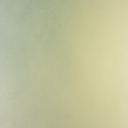
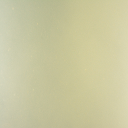
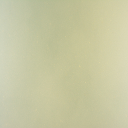
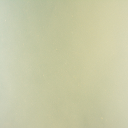
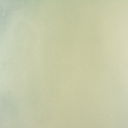
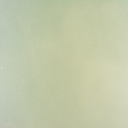
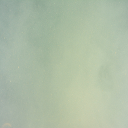
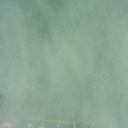
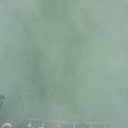
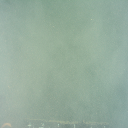
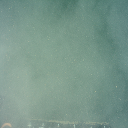
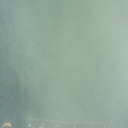
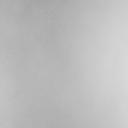
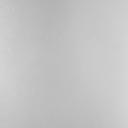
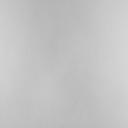
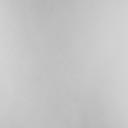
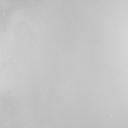
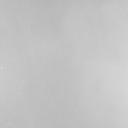
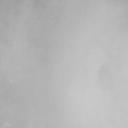
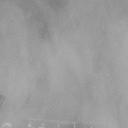
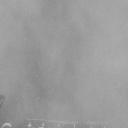
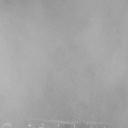
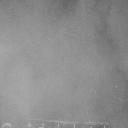
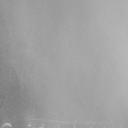
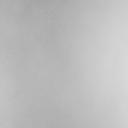
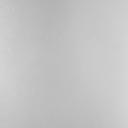
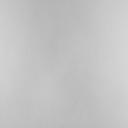
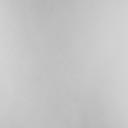
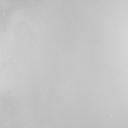
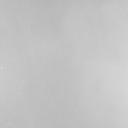
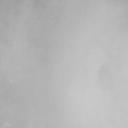
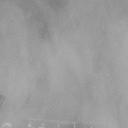
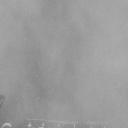
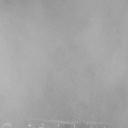
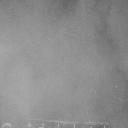
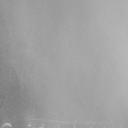
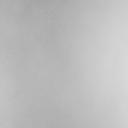
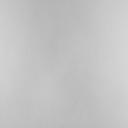
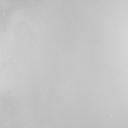
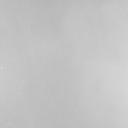
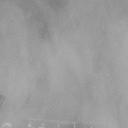
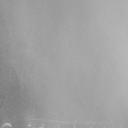
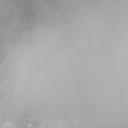
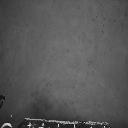
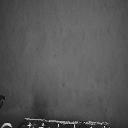
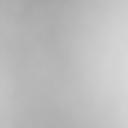
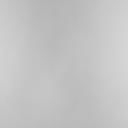
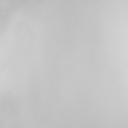
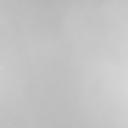
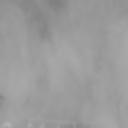
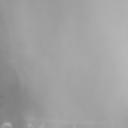
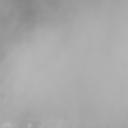
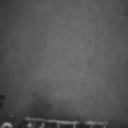
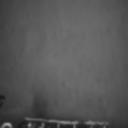
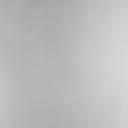
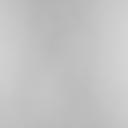
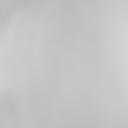
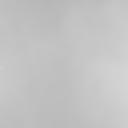
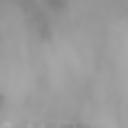
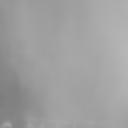
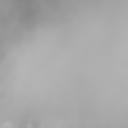
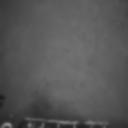
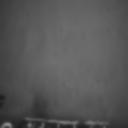
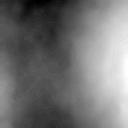
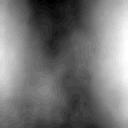
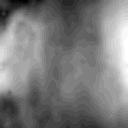
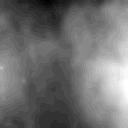
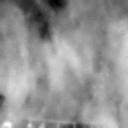
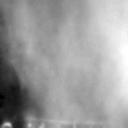
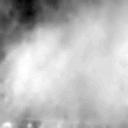
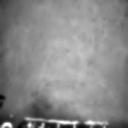
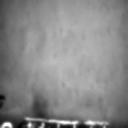

In [66]:
# See the images output
pipeline.images


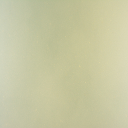
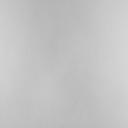
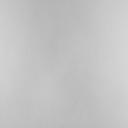
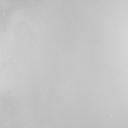
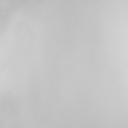
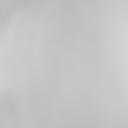
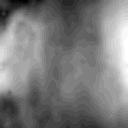

In [65]:
pipeline.images.show(image_number=2)

# Export Images to file

In [109]:
pipeline.save_images(image_format="png")

☁ paidiverpy ☁  |       INFO | 2025-05-19 19:52:31 | Saving images from step: last
☁ paidiverpy ☁  |       INFO | 2025-05-19 19:52:31 | Saving images
☁ paidiverpy ☁  |       INFO | 2025-05-19 19:52:31 | Images are saved to: output


☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:16 | Images are saved to: output
